In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Ashutosh Bhatt\Churn_Model\Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

**This dataset containing 10,000 rows and 14 columns . Dataset has Customer identifiers like Rownumber, Customer ID.
Demographics- Geography (customer location). Account details - balance, has credit card.**

In [5]:
info_df = pd.DataFrame({
    'Column': df.columns,
    'NonNullCount' : df.notnull().sum(),
    'NullCount': df.isnull().sum(),
    'Dtype'   :df.dtypes }).reset_index(drop=True)
print(info_df)


             Column  NonNullCount  NullCount    Dtype
0         RowNumber         10000          0    int64
1        CustomerId         10000          0    int64
2           Surname         10000          0   object
3       CreditScore         10000          0    int64
4         Geography         10000          0   object
5            Gender         10000          0   object
6               Age         10000          0    int64
7            Tenure         10000          0    int64
8           Balance         10000          0  float64
9     NumOfProducts         10000          0    int64
10        HasCrCard         10000          0    int64
11   IsActiveMember         10000          0    int64
12  EstimatedSalary         10000          0  float64
13           Exited         10000          0    int64


**There are zero missing values . All the 10,000 rows across 14 columns are fully populated.**

In [6]:
num_cols = df.select_dtypes(include=[int,float])

In [7]:
cat_cols = df.select_dtypes(exclude=[int,float])

**Handling Oultiers**

In [8]:
outliers_features = ['CreditScore','Age','NumOfProducts']

In [9]:
for col in outliers_features:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr = q3-q1

    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr

    df[col] = np.clip(df[col],a_min=lower_bound,a_max=upper_bound)
print("Outliers Capped successfully")
df.to_csv("Treated Outliers.csv",index=False)
df.head()

Outliers Capped successfully


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1.0,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1.0,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3.0,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2.0,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1.0,1,1,79084.10,0


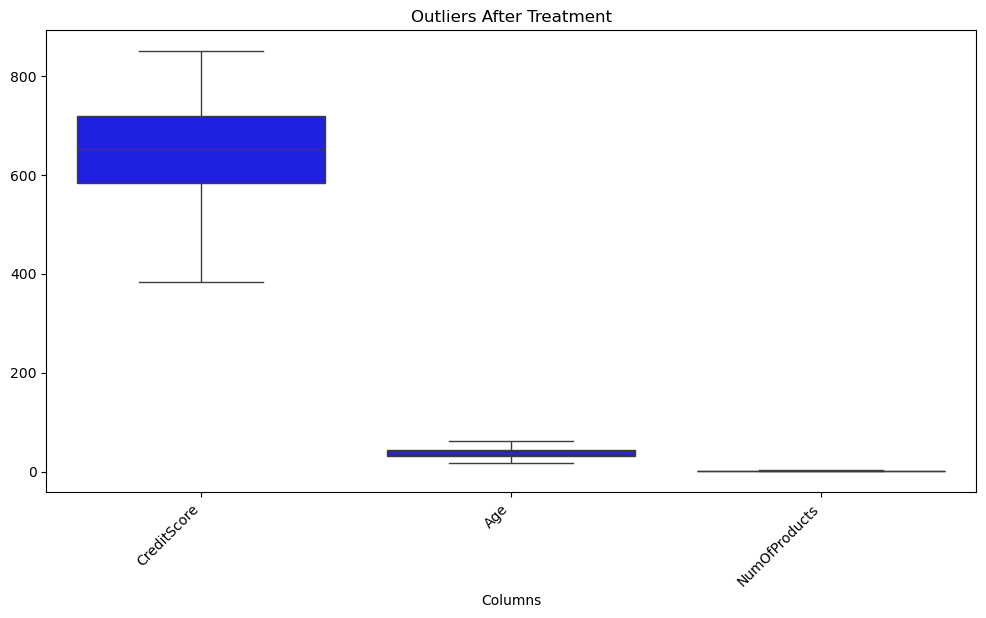

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data= df[outliers_features] , color='blue')
plt.title('Outliers After Treatment')
plt.xticks(rotation=45,ha='right')
plt.xlabel('Columns')
plt.show()

**Data Featuring**

In [11]:
df_1 = pd.read_csv(r"C:\Users\Ashutosh Bhatt\Churn_Model\Treated Outliers.csv")
df_1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1.0,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1.0,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3.0,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2.0,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1.0,1,1,79084.10,0


In [12]:
# dropping column - Row number and Customer ID
df_1= df_1.drop(columns=['RowNumber','CustomerId','Surname'])
# Adding new columns
df_1['BalanceToSalaryRatio'] = df['Balance']/(df['EstimatedSalary']+1)
df_1['IsZeroBalance'] = (df['Balance']==0).astype(int)
df_1['AgeGroup'] = pd.cut(df['Age'],bins=[0,30,45,65,100],labels=['Young','Middle','Senior','Elderly'])
df_1['ProductPerYear'] = df['NumOfProducts']/(df['Tenure']+1)
df_1['Geo_Gender'] = df['Geography']+'_'+df['Gender']
print(df_1 )
df_1.to_csv("Data featured.csv", index=False)

      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0             619    France  Female   42       2       0.00            1.0   
1             608     Spain  Female   41       1   83807.86            1.0   
2             502    France  Female   42       8  159660.80            3.0   
3             699    France  Female   39       1       0.00            2.0   
4             850     Spain  Female   43       2  125510.82            1.0   
...           ...       ...     ...  ...     ...        ...            ...   
9995          771    France    Male   39       5       0.00            2.0   
9996          516    France    Male   35      10   57369.61            1.0   
9997          709    France  Female   36       7       0.00            1.0   
9998          772   Germany    Male   42       3   75075.31            2.0   
9999          792    France  Female   28       4  130142.79            1.0   

      HasCrCard  IsActiveMember  EstimatedSalary  Exited  \
0  

**Categorical Encoding**

In [13]:
df_2 = pd.read_csv(r"C:\Users\Ashutosh Bhatt\Churn_Model\Data featured.csv")
df_2.head()
print(df_2.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'BalanceToSalaryRatio', 'IsZeroBalance', 'AgeGroup', 'ProductPerYear', 'Geo_Gender']


In [14]:
# Ordinal Encoding choose for Age Group column its has clear order rank Young,Middle,Senior,Elderly
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OrdinalEncoder
ord_encode = OrdinalEncoder()
df_2['AgeGroup_Encoded'] = ord_encode.fit_transform(df_2[['AgeGroup']])	


In [15]:
# Lable  Encoding
from sklearn.preprocessing import LabelEncoder
label_encode = LabelEncoder()
df_2['Gender_Encoded'] = label_encode.fit_transform(df_2['Gender'].astype(str))
df_2['Geography_Encoded'] = label_encode.fit_transform(df_2['Geography'].astype(str))
df_2['Geo_Gender_Encoded'] = label_encode.fit_transform(df_2['Geo_Gender'].astype(str))
print(df_2)

      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0             619    France  Female   42       2       0.00            1.0   
1             608     Spain  Female   41       1   83807.86            1.0   
2             502    France  Female   42       8  159660.80            3.0   
3             699    France  Female   39       1       0.00            2.0   
4             850     Spain  Female   43       2  125510.82            1.0   
...           ...       ...     ...  ...     ...        ...            ...   
9995          771    France    Male   39       5       0.00            2.0   
9996          516    France    Male   35      10   57369.61            1.0   
9997          709    France  Female   36       7       0.00            1.0   
9998          772   Germany    Male   42       3   75075.31            2.0   
9999          792    France  Female   28       4  130142.79            1.0   

      HasCrCard  IsActiveMember  EstimatedSalary  Exited  \
0  

In [16]:
df_2 = df_2.drop(columns=df_2.select_dtypes(include='object').columns)
df_2.to_csv("Encoded Churn Dataset.csv", index=False)
df_2.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceToSalaryRatio,IsZeroBalance,ProductPerYear,AgeGroup_Encoded,Gender_Encoded,Geography_Encoded,Geo_Gender_Encoded
0,619,42,2,0.00,1.0,1,1,101348.88,1,0.000000,1,0.333333,0.0,0,0,0
1,608,41,1,83807.86,1.0,0,1,112542.58,0,0.744670,0,0.500000,0.0,0,2,4
2,502,42,8,159660.80,3.0,1,0,113931.57,1,1.401362,0,0.333333,0.0,0,0,0
3,699,39,1,0.00,2.0,0,0,93826.63,0,0.000000,1,1.000000,0.0,0,0,0
4,850,43,2,125510.82,1.0,1,1,79084.10,0,1.587035,0,0.333333,0.0,0,2,4


**Scaling**

In [17]:
features = ['CreditScore','Age','Tenure','Balance','EstimatedSalary','NumOfProducts','BalanceToSalaryRatio','ProductPerYear']

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_2[features] = scaler.fit_transform(df_2[features])
print(df_2[features])
df_2.to_csv("Scaled Churn Dataset.csv")

      CreditScore       Age    Tenure   Balance  EstimatedSalary  \
0       -0.326878  0.342615 -1.041760 -1.225848         0.021886   
1       -0.440804  0.240011 -1.387538  0.117350         0.216534   
2       -1.538636  0.342615  1.032908  1.333053         0.240687   
3        0.501675  0.034803 -1.387538 -1.225848        -0.108918   
4        2.065569  0.445219 -1.041760  0.785728        -0.365276   
...           ...       ...       ...       ...              ...   
9995     1.247373  0.034803 -0.004426 -1.225848        -0.066419   
9996    -1.393640 -0.375612  1.724464 -0.306379         0.027988   
9997     0.605244 -0.273008  0.687130 -1.225848        -1.008643   
9998     1.257730  0.342615 -0.695982 -0.022608        -0.125231   
9999     1.464868 -1.093840 -0.350204  0.859965        -1.076370   

      NumOfProducts  BalanceToSalaryRatio  ProductPerYear  
0         -0.924827             -0.037882       -0.098704  
1         -0.924827             -0.030439        0.396531  
2  

In [22]:
import joblib
joblib.dump(scaler, 'scaler.pkl') 

['scaler.pkl']